In [4]:
import pandas as pd
import geemap
from google.colab import drive
import geopandas as gpd
import ee

drive.mount('/content/drive')

ee.Authenticate()
ee.Initialize(project='lucasvituri')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# Cargamos las capas vectoriales (Shapefiles)
provincias = gpd.read_file('/content/drive/MyDrive/INTROSIG_T1_GEE/Provincias.shp')
# Reproyectar y asignar de nuevo a la variable
provincias = provincias.to_crs('EPSG:4326') # Dejar los crs iguales para la intersección de datos
print("CRS de provincias después de reproyectar: ", provincias.crs)

catastro = gpd.read_file('/content/drive/MyDrive/INTROSIG_T1_GEE/5__cubierta_frutal_de_pol_gonos_regi_n_de_valpara_so_2025.shp')
# Reproyectar y asignar de nuevo a la variable
catastro = catastro.to_crs('EPSG:4326')
print("CRS de catastro después de reproyectar: ", catastro.crs)

# INTERSECCIÓN ESPACIAL: Traspasamos la información de la provincia a cada parcela
# Esto une ambas tablas basándose en su ubicación geográfica (superposición)
catastro_con_provincia = gpd.overlay(catastro, provincias, how='intersection')


CRS de catastro después de reproyectar:  EPSG:4326


In [32]:
# 4. Filtro simplificado y robusto
PROVINCIA = 'San Felipe'
ESPECIE_1 = 'PALTO'
ESPECIE_2 = 'VID DE MESA'

# Filtramos la provincia
prov_gdf = provincias[provincias['Provincia'] == PROVINCIA]

# Filtramos las parcelas de la provincia por especie
esp1_sf = catastro_con_provincia[(catastro_con_provincia['Provincia'] == PROVINCIA) & (catastro_con_provincia['ESPECIE'] == ESPECIE_1)]
esp2_sf = catastro_con_provincia[(catastro_con_provincia['Provincia'] == PROVINCIA) & (catastro_con_provincia['ESPECIE'] == ESPECIE_2)]

print(f"Parcelas en {PROVINCIA}: {ESPECIE_1} ({len(esp1_sf)}), {ESPECIE_2} ({len(esp2_sf)})")

Parcelas en San Felipe: PALTO (462), VID DE MESA (1618)


In [36]:
def extract_by_bbox(gdf, label):
    # Usamos el bounding box (rectángulo envolvente) para evitar el error de tamaño de payload
    region = geemap.geopandas_to_ee(gdf).geometry().bounds()

    smap_col = ee.ImageCollection("NASA/SMAP/SPL4SMGP/008")
    ndvi_col = ee.ImageCollection("MODIS/061/MOD13Q1")

    def monthly_stat(m):
        m = ee.Number(m)
        ini = ee.Date.fromYMD(2023, m, 1)
        fin = ini.advance(1, 'month')

        # Corregido: .subtract(273.15) para convertir Kelvin a Celsius
        temp = smap_col.filterDate(ini, fin).select('surface_temp').mean().subtract(273.15).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=region, scale=11000).get('surface_temp', 0)

        ndvi = ndvi_col.filterDate(ini, fin).select('NDVI').mean().multiply(0.0001).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=region, scale=250).get('NDVI', 0)

        return ee.Feature(None, {'Mes': m, 'Temperatura': temp, 'NDVI': ndvi, 'Especie': label})

    return ee.FeatureCollection(ee.List.sequence(1, 12).map(monthly_stat)).getInfo()

try:
    print("Extrayendo datos usando envolventes geográficas...")
    res_esp1 = extract_by_bbox(esp1_sf, ESPECIE_1)
    res_esp2 = extract_by_bbox(esp2_sf, ESPECIE_2)

    df_comparativo = pd.DataFrame([f['properties'] for f in res_esp1['features']] +
                                  [f['properties'] for f in res_esp2['features']])
    display(df_comparativo)
except Exception as e:
    print(f"Error: {e}")

Extrayendo datos usando envolventes geográficas...


,Especie,Mes,NDVI,Temperatura
0,PALTO,1,0.354748,21.271767
1,PALTO,2,0.339415,22.536172
2,PALTO,3,0.344797,21.048248
3,PALTO,4,0.341919,16.172312
4,PALTO,5,0.318007,12.756767
5,PALTO,6,0.326030,10.701060
6,PALTO,7,0.407400,9.143240
7,PALTO,8,0.478196,10.853752
8,PALTO,9,0.517783,10.470324
9,PALTO,10,0.450360,13.358699


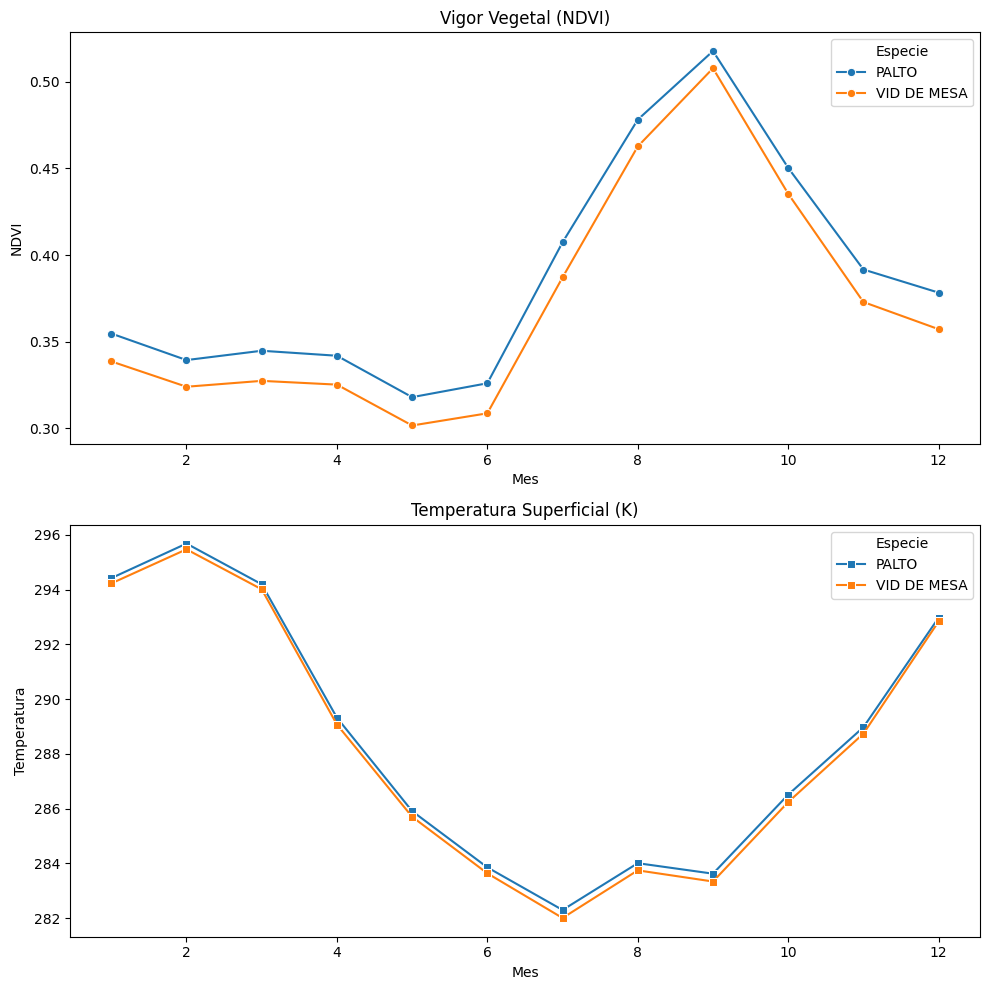

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

sns.lineplot(data=df_comparativo, x='Mes', y='NDVI', hue='Especie', marker='o', ax=ax1)
ax1.set_title('Vigor Vegetal (NDVI)')

sns.lineplot(data=df_comparativo, x='Mes', y='Temperatura', hue='Especie', marker='s', ax=ax2)
ax2.set_title('Temperatura Superficial (K)')

plt.tight_layout()
plt.show()

In [38]:
# Crearemos el mapa enfocado en el mes más critico del verano (Febrero)
mapa_frutales = geemap.Map()

# Definimos las parcelas en formato EE para el mapa
# Usamos los nombres de las variables creadas en la celda 2ERphReqtMpf
parcelas_esp1_ee = geemap.geopandas_to_ee(esp1_sf)
parcelas_esp2_ee = geemap.geopandas_to_ee(esp2_sf)

mapa_frutales.centerObject(parcelas_esp1_ee, zoom=10)

# Filtramos las imágenes de satélite especificamente para Febrero de 2023
smap_feb = ee.ImageCollection("NASA/SMAP/SPL4SMGP/008")\
             .filterDate('2023-02-01', '2023-02-28').select('sm_profile').mean()
ndvi_feb = ee.ImageCollection("MODIS/061/MOD13Q1")\
             .filterDate('2023-02-01', '2023-02-28').select('NDVI').mean().multiply(0.0001)

# Añadimos las capas Raster (usamos la zona de estudio filtrada en prov_gdf)
zona_ee = geemap.geopandas_to_ee(prov_gdf)

paleta_h = ['#d73027', '#fdae61', '#a6d96a', '#1a9641']
mapa_frutales.addLayer(smap_feb.clip(zona_ee), {'min': 0, 'max': 0.5, 'palette': paleta_h}, 'Humedad (Feb)')
mapa_frutales.addLayer(ndvi_feb.clip(zona_ee), {'min': 0.2, 'max': 0.8, 'palette': ['white', 'green']}, 'NDVI (Feb)')

# Añadimos los polígonos de las plantaciones por encima
bordes_palto = ee.Image().byte().paint(featureCollection=parcelas_esp1_ee, color=1, width=2)
mapa_frutales.addLayer(bordes_palto, {'palette': ['black']}, f'Plantaciones de {ESPECIE_1}')

bordes_vid = ee.Image().byte().paint(featureCollection=parcelas_esp2_ee, color=1, width=2)
mapa_frutales.addLayer(bordes_vid, {'palette': ['purple']}, f'Plantaciones de {ESPECIE_2}')

display(mapa_frutales)

Map(center=[-32.82888198523735, -70.90494833989223], controls=(WidgetControl(options=['position', 'transparent…